In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Load the Telco Customer Churn dataset
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded successfully!
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [22]:
print("\n--- Dataset Info ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Duplicate rows ---")
print(df.duplicated().sum())

print("\n--- Churn distribution ---")
print(df['Churn'].value_counts(normalize=True))


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  70

In [24]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill the 11 missing TotalCharges with 0 (new customers)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Convert Churn to binary
df['Churn_binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Drop customerID
df = df.drop('customerID', axis=1)

print("Cleaning done.")
print(df.isnull().sum().sum(), "missing values remaining")

Cleaning done.
0 missing values remaining


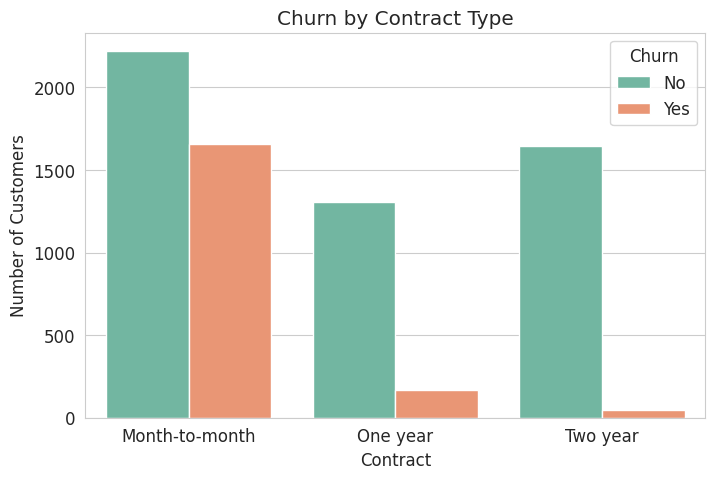

Churn                 No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887305  0.112695
Two year        0.971681  0.028319


In [25]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')
plt.title('Churn by Contract Type')
plt.xlabel('Contract')
plt.ylabel('Number of Customers')
plt.show()

# Exact percentages
print(df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack())

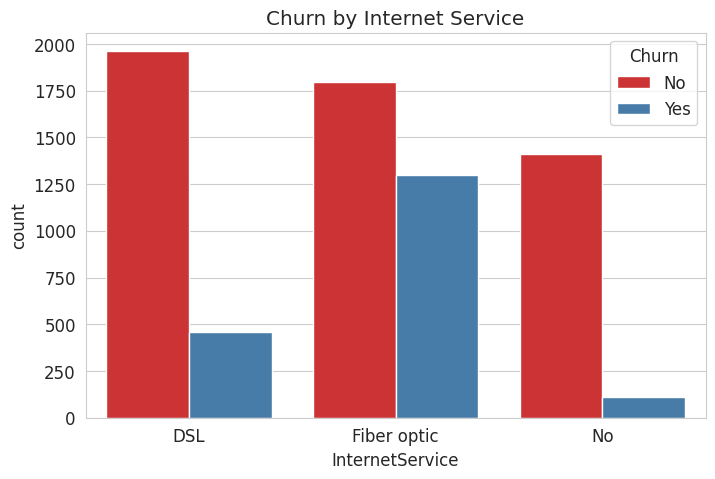

Churn                  No       Yes
InternetService                    
DSL              0.810409  0.189591
Fiber optic      0.581072  0.418928
No               0.925950  0.074050


In [26]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='InternetService', hue='Churn', palette='Set1')
plt.title('Churn by Internet Service')
plt.show()

print(df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack())

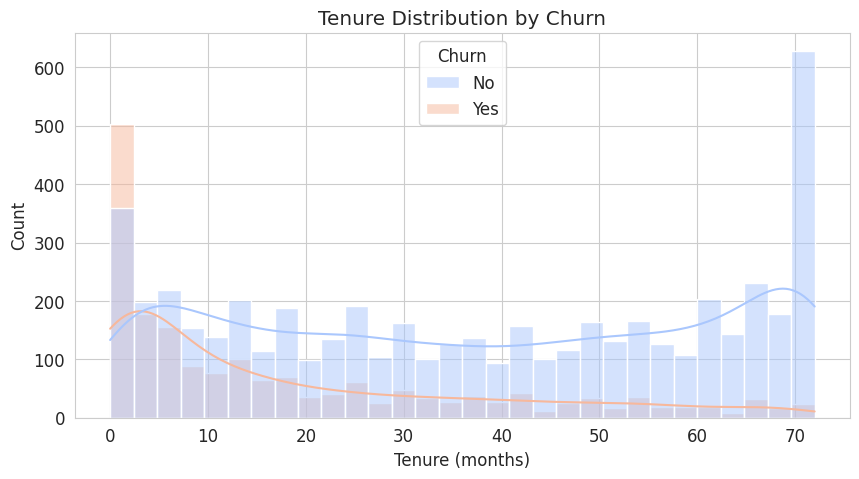

In [27]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True, palette='coolwarm')
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.show()

/tmp/ipykernel_1044/511806803.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set3')


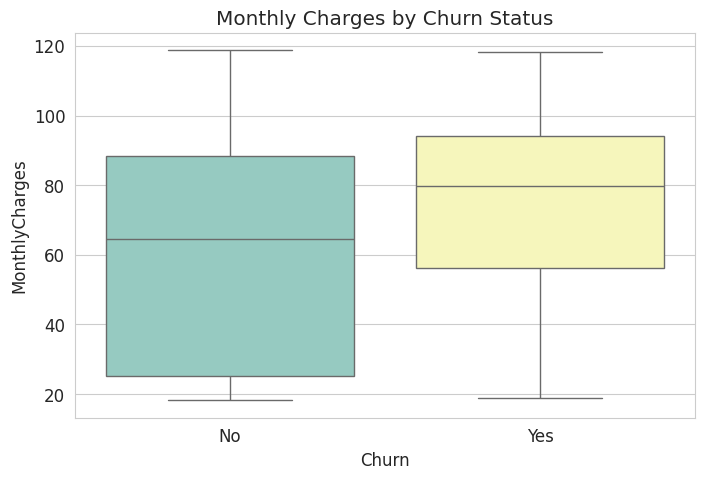

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set3')
plt.title('Monthly Charges by Churn Status')
plt.show()

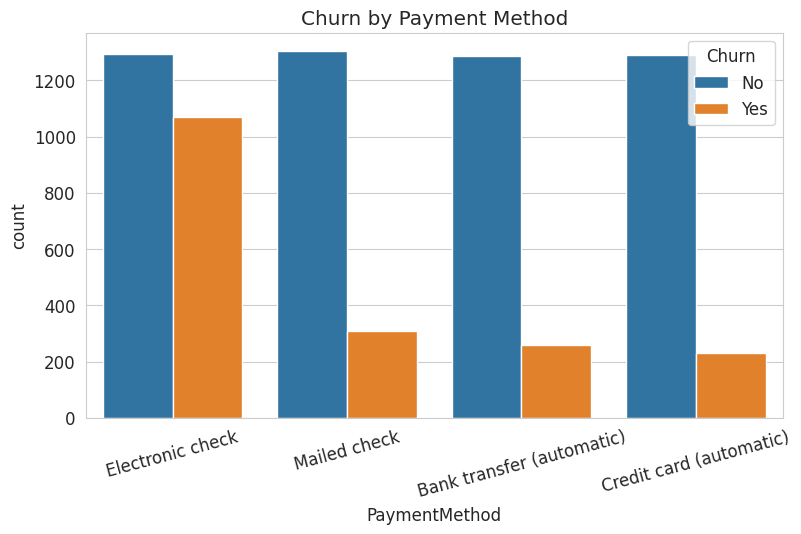

In [29]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.xticks(rotation=15)
plt.title('Churn by Payment Method')
plt.show()

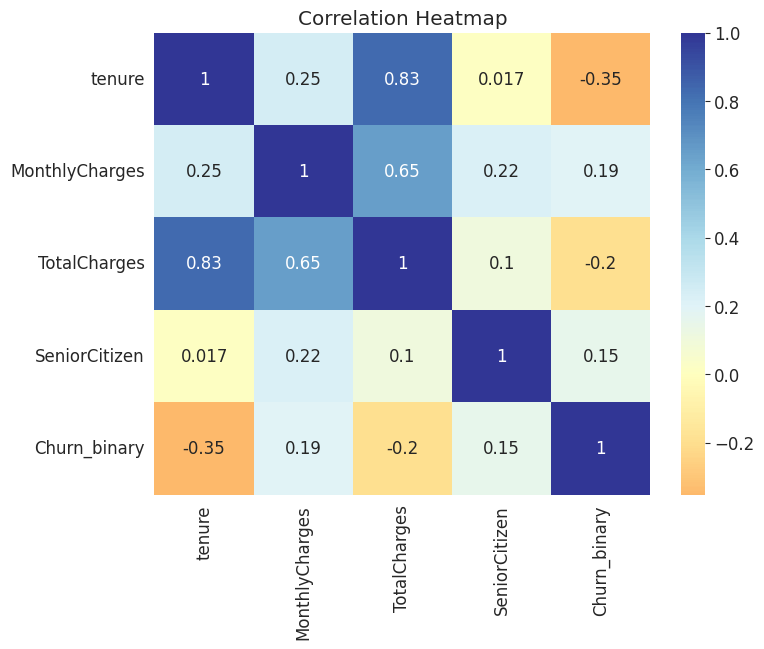

In [30]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_binary']
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='RdYlBu', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [31]:
# ==========================================
# TASK 2: PREDICTIVE MODEL BUILDING
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Create a copy for machine learning
model_df = df.copy()

# Churn_binary is our target, so remove the original text Churn column
model_df = model_df.drop('Churn', axis=1)

# Separate features (X) and target (y)
X = model_df.drop('Churn_binary', axis=1)
y = model_df['Churn_binary']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features shape: (7043, 19)
Target shape: (7043,)

Target distribution:
Churn_binary
0    5174
1    1869
Name: count, dtype: int64


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5634
Testing samples: 1409


In [37]:
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [39]:
logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train model
logistic_model.fit(X_train, y_train)

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [40]:
y_pred = logistic_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("LOGISTIC REGRESSION RESULTS")
print("---------------------------")
print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

LOGISTIC REGRESSION RESULTS
---------------------------
Accuracy : 0.806
Precision: 0.657
Recall   : 0.559
F1 Score : 0.604

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



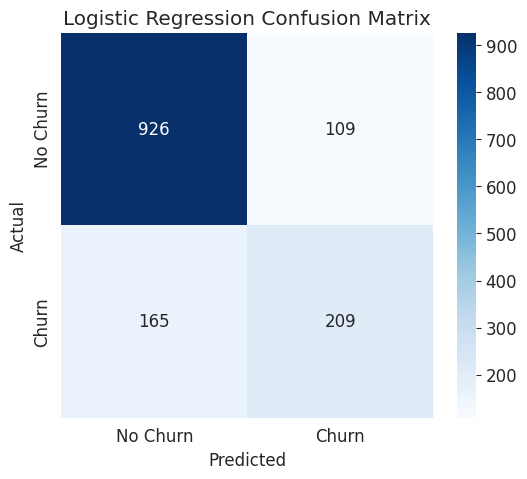

In [41]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced'
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("RANDOM FOREST RESULTS")
print("---------------------")
print(f"Accuracy : {accuracy_score(y_test, rf_pred):.3f}")
print(f"Precision: {precision_score(y_test, rf_pred):.3f}")
print(f"Recall   : {recall_score(y_test, rf_pred):.3f}")
print(f"F1 Score : {f1_score(y_test, rf_pred):.3f}")

RANDOM FOREST RESULTS
---------------------
Accuracy : 0.784
Precision: 0.621
Recall   : 0.473
F1 Score : 0.537


In [45]:
# Create model comparison table

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred)
    ],
    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred)
    ]
})

print("MODEL COMPARISON")
display(results.round(3))

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.806,0.657,0.559,0.604
1,Random Forest,0.784,0.621,0.473,0.537


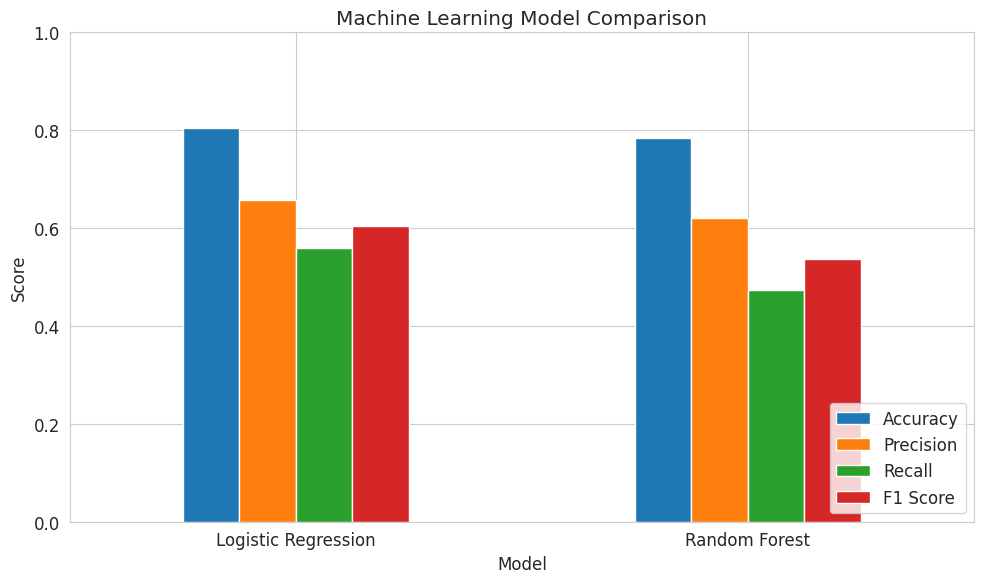

In [46]:
results_plot = results.set_index('Model')

results_plot.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Machine Learning Model Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [47]:
# Model Comparison

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred)
    ],
    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred)
    ]
})

display(results.round(3))

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.806,0.657,0.559,0.604
1,Random Forest,0.784,0.621,0.473,0.537


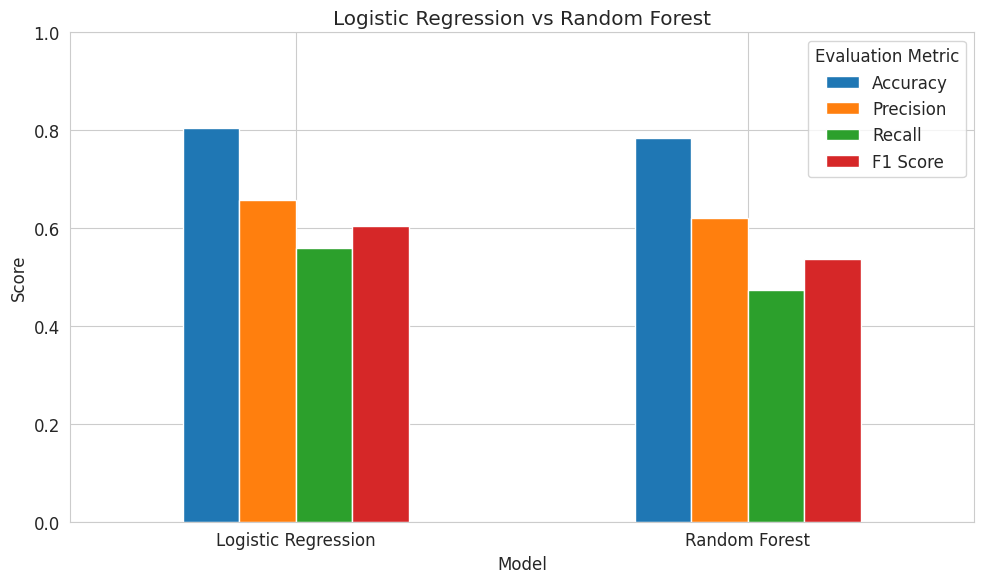

In [48]:
# Visualize model performance

results_plot = results.set_index('Model')

results_plot.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Logistic Regression vs Random Forest')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Evaluation Metric')
plt.tight_layout()
plt.show()

### Model Comparison

The Logistic Regression and Random Forest models were evaluated using accuracy, precision, recall, and F1-score.

Since the churn dataset contains more non-churn customers than churn customers, accuracy alone is not sufficient to evaluate model performance. Recall and F1-score are also important because they show how effectively the model identifies customers who actually churn.

In [49]:
# Extract feature names from the Logistic Regression model

feature_names = logistic_model.named_steps[
    'preprocessor'
].get_feature_names_out()

# Get coefficients
coefficients = logistic_model.named_steps[
    'classifier'
].coef_[0]

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Absolute coefficient for ranking
feature_importance['Importance'] = abs(
    feature_importance['Coefficient']
)

top_features = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(15)

display(top_features[['Feature', 'Coefficient', 'Importance']].round(3))

,Feature,Coefficient,Importance
1,num__tenure,-1.258,1.258
38,cat__Contract_Two year,-0.777,0.777
15,cat__InternetService_DSL,-0.649,0.649
16,cat__InternetService_Fiber optic,0.634,0.634
2,num__MonthlyCharges,-0.592,0.592
36,cat__Contract_Month-to-month,0.583,0.583
3,num__TotalCharges,0.536,0.536
39,cat__PaperlessBilling_No,-0.343,0.343
25,cat__DeviceProtection_No internet service,-0.300,0.300
17,cat__InternetService_No,-0.300,0.300


cat__Contract_Month-to-month
cat__InternetService_Fiber optic
cat__PaymentMethod_Electronic check
num__tenure
...

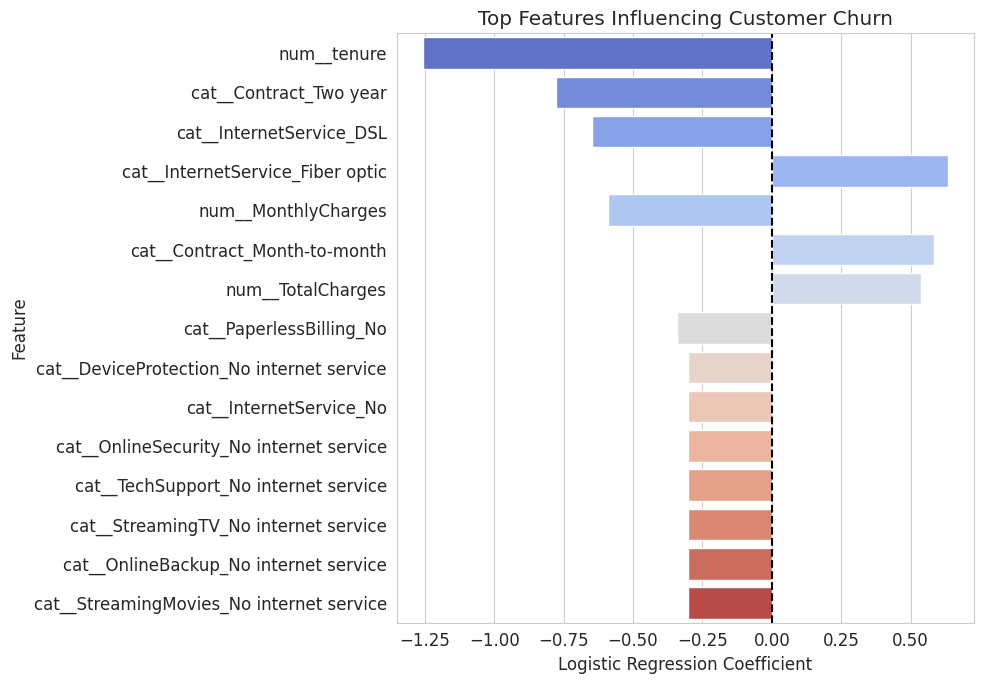

In [50]:
# Top influential features

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x='Coefficient',
    y='Feature',
    hue='Feature',
    palette='coolwarm',
    legend=False
)

plt.axvline(x=0, color='black', linestyle='--')

plt.title('Top Features Influencing Customer Churn')
plt.xlabel('Logistic Regression Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Feature Influence

The Logistic Regression coefficients were examined to understand which variables contributed most strongly to churn predictions.

Features with positive coefficients increase the model's predicted likelihood of churn, while features with negative coefficients decrease it. The magnitude of the coefficient indicates the strength of its influence within the model.

The results suggest that customer contract characteristics, tenure, internet service, payment method, and service-related characteristics contribute to churn prediction.

These relationships are predictive associations and should not be interpreted as evidence that the variables directly cause customer churn.

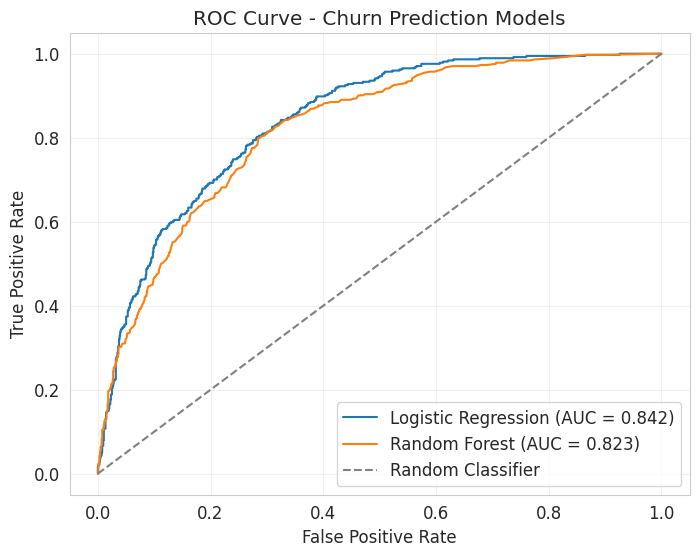

Logistic Regression AUC: 0.842
Random Forest AUC: 0.823


In [51]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability predictions
log_probs = logistic_model.predict_proba(X_test)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# AUC scores
log_auc = roc_auc_score(y_test, log_probs)
rf_auc = roc_auc_score(y_test, rf_probs)

# ROC curve values
log_fpr, log_tpr, _ = roc_curve(y_test, log_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(8, 6))

plt.plot(
    log_fpr,
    log_tpr,
    label=f'Logistic Regression (AUC = {log_auc:.3f})'
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f'Random Forest (AUC = {rf_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='gray',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Churn Prediction Models')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Logistic Regression AUC: {log_auc:.3f}")
print(f"Random Forest AUC: {rf_auc:.3f}")

## Project Limitations

1. The dataset represents a particular telecommunications customer sample, so the findings may not generalize to every telecom company or market.

2. The dataset contains more non-churn customers than churn customers, creating class imbalance.

3. The models identify statistical and predictive relationships rather than proving causal relationships.

4. Customer behavior may change over time, meaning a model trained on historical data may require retraining before being used on future customers.

5. Additional information such as customer complaints, service quality, geographic location, and competitor pricing could potentially improve churn prediction.

## Project Limitations

1. The dataset represents a particular telecommunications customer sample, so the findings may not generalize to every telecom company or market.

2. The dataset contains more non-churn customers than churn customers, creating class imbalance.

3. The models identify statistical and predictive relationships rather than proving causal relationships.

4. Customer behavior may change over time, meaning a model trained on historical data may require retraining before being used on future customers.

5. Additional information such as customer complaints, service quality, geographic location, and competitor pricing could potentially improve churn prediction.

In [52]:
display(results.round(3))

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.806,0.657,0.559,0.604
1,Random Forest,0.784,0.621,0.473,0.537


In [53]:
display(top_features[['Feature', 'Coefficient']].round(3))

,Feature,Coefficient
1,num__tenure,-1.258
38,cat__Contract_Two year,-0.777
15,cat__InternetService_DSL,-0.649
16,cat__InternetService_Fiber optic,0.634
2,num__MonthlyCharges,-0.592
36,cat__Contract_Month-to-month,0.583
3,num__TotalCharges,0.536
39,cat__PaperlessBilling_No,-0.343
25,cat__DeviceProtection_No internet service,-0.300
17,cat__InternetService_No,-0.300


# TASK 3: INTERACTIVE INSIGHTS DASHBOARD

## Objective

The objective of this task is to develop an interactive dashboard that allows users to explore customer churn patterns in the Telco Customer Churn dataset.

The dashboard includes multiple visualization types and interactive filters to help examine how customer characteristics relate to churn.

In [54]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("Plotly imported successfully!")

Plotly imported successfully!


In [55]:
total_customers = len(df)
churned_customers = (df['Churn'] == 'Yes').sum()
non_churned_customers = (df['Churn'] == 'No').sum()
churn_rate = (churned_customers / total_customers) * 100

print(f"Total Customers: {total_customers:,}")
print(f"Churned Customers: {churned_customers:,}")
print(f"Non-Churned Customers: {non_churned_customers:,}")
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Total Customers: 7,043
Churned Customers: 1,869
Non-Churned Customers: 5,174
Overall Churn Rate: 26.54%


In [56]:
churn_counts = df['Churn'].value_counts().reset_index()
churn_counts.columns = ['Churn', 'Customers']

fig = px.pie(
    churn_counts,
    names='Churn',
    values='Customers',
    hole=0.4,
    title='Customer Churn Distribution',
    color='Churn',
    color_discrete_map={
        'Yes': '#EF553B',
        'No': '#636EFA'
    }
)

fig.show()

In [57]:
contract_churn = (
    df.groupby(['Contract', 'Churn'])
    .size()
    .reset_index(name='Customers')
)

fig = px.bar(
    contract_churn,
    x='Contract',
    y='Customers',
    color='Churn',
    barmode='group',
    title='Customer Churn by Contract Type',
    labels={
        'Contract': 'Contract Type',
        'Customers': 'Number of Customers'
    }
)

fig.show()

In [58]:
fig = px.histogram(
    df,
    x='MonthlyCharges',
    color='Churn',
    nbins=30,
    marginal='box',
    title='Monthly Charges Distribution by Churn Status',
    labels={
        'MonthlyCharges': 'Monthly Charges'
    }
)

fig.show()

In [59]:
internet_churn = (
    df.groupby(['InternetService', 'Churn'])
    .size()
    .reset_index(name='Customers')
)

fig = px.bar(
    internet_churn,
    x='InternetService',
    y='Customers',
    color='Churn',
    barmode='group',
    title='Churn by Internet Service',
    labels={
        'InternetService': 'Internet Service',
        'Customers': 'Number of Customers'
    }
)

fig.show()

In [60]:
fig = px.scatter(
    df,
    x='tenure',
    y='MonthlyCharges',
    color='Churn',
    hover_data=['Contract', 'InternetService', 'PaymentMethod'],
    title='Tenure vs Monthly Charges by Churn Status',
    labels={
        'tenure': 'Tenure (Months)',
        'MonthlyCharges': 'Monthly Charges'
    }
)

fig.show()

In [61]:
fig = px.histogram(
    df,
    x='tenure',
    color='Churn',
    facet_col='Contract',
    nbins=20,
    title='Customer Tenure and Churn by Contract Type',
    labels={'tenure': 'Tenure (Months)'}
)

fig.update_layout(
    height=500
)

fig.show()

In [62]:
fig = go.Figure()

contracts = df['Contract'].unique()

for i, contract in enumerate(contracts):

    filtered = df[df['Contract'] == contract]

    counts = filtered['Churn'].value_counts()

    fig.add_trace(
        go.Bar(
            x=counts.index,
            y=counts.values,
            name=contract,
            visible=(i == 0)
        )
    )

buttons = []

for i, contract in enumerate(contracts):

    visible = [False] * len(contracts)
    visible[i] = True

    buttons.append(
        dict(
            label=contract,
            method='update',
            args=[
                {'visible': visible},
                {
                    'title':
                    f'Churn Distribution: {contract}'
                }
            ]
        )
    )

fig.update_layout(
    title=f'Churn Distribution: {contracts[0]}',
    xaxis_title='Churn',
    yaxis_title='Number of Customers',

    updatemenus=[
        dict(
            buttons=buttons,
            direction='down',
            showactive=True,
            x=0.0,
            y=1.15
        )
    ]
)

fig.show()

In [63]:
fig.write_html("interactive_churn_dashboard.html")

print("Dashboard saved successfully!")

Dashboard saved successfully!


## Task 3: Dashboard Insights

The interactive dashboard provides an overview of customer churn and allows users to explore patterns across different customer characteristics.

The dashboard indicates that churn varies considerably depending on contract type, customer tenure, internet service, monthly charges, and other service characteristics.

Interactive Plotly visualizations allow viewers to hover over observations, zoom into charts, hide or display categories, and explore selected customer groups.

### Limitations and Potential Biases

The dataset represents a specific telecommunications customer sample and may not represent customers in all geographic regions or telecommunications markets.

The target classes are also imbalanced because there are more non-churn customers than churn customers.

Some potentially useful variables, such as customer complaints, network quality, competitor prices, geographic location, and customer satisfaction, are unavailable.

Finally, the observed relationships represent associations in historical data and should not automatically be interpreted as causal relationships.

In [64]:
!pip -q install dash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 46.8 MB/s eta 0:00:00


In [65]:
from dash import Dash, dcc, html, Input, Output
import plotly.express as px
import pandas as pd

In [66]:
# Create a copy specifically for the dashboard
dashboard_df = df.copy()

print("Dashboard dataset shape:", dashboard_df.shape)
print(dashboard_df.head())

Dashboard dataset shape: (7043, 21)
   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  ...  \
0  No phone service             DSL             No          Yes  ...   
1                No             DSL            Yes           No  ...   
2                No             DSL            Yes          Yes  ...   
3  No phone service             DSL            Yes           No  ...   
4                No     Fiber optic             No           No  ...   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          No          No              No  M

In [67]:
# =============================================
# TASK 3: INTERACTIVE CUSTOMER CHURN DASHBOARD
# =============================================

app = Dash(__name__)

# Available filter options
contract_options = sorted(dashboard_df['Contract'].dropna().unique())
internet_options = sorted(dashboard_df['InternetService'].dropna().unique())

app.layout = html.Div([

    # TITLE
    html.H1(
        "Telco Customer Churn Dashboard",
        style={
            'textAlign': 'center',
            'color': '#1F3A5F',
            'marginBottom': '5px'
        }
    ),

    html.P(
        "Interactive analysis of customer churn patterns",
        style={
            'textAlign': 'center',
            'color': '#666'
        }
    ),

    html.Hr(),

    # FILTERS
    html.Div([

        html.Div([
            html.Label("Contract Type"),
            dcc.Dropdown(
                id='contract-filter',
                options=[
                    {'label': x, 'value': x}
                    for x in contract_options
                ],
                value=[],
                multi=True,
                placeholder="All Contract Types"
            )
        ], style={
            'width': '45%',
            'display': 'inline-block',
            'marginRight': '5%'
        }),

        html.Div([
            html.Label("Internet Service"),
            dcc.Dropdown(
                id='internet-filter',
                options=[
                    {'label': x, 'value': x}
                    for x in internet_options
                ],
                value=[],
                multi=True,
                placeholder="All Internet Services"
            )
        ], style={
            'width': '45%',
            'display': 'inline-block'
        })

    ], style={
        'padding': '20px',
        'backgroundColor': '#F4F6F7'
    }),

    # KPI CARDS
    html.Div([

        html.Div([
            html.H3("Total Customers"),
            html.H2(id='total-customers')
        ], style={
            'width': '22%',
            'display': 'inline-block',
            'textAlign': 'center',
            'backgroundColor': '#3498DB',
            'color': 'white',
            'padding': '15px',
            'margin': '1%'
        }),

        html.Div([
            html.H3("Churned Customers"),
            html.H2(id='churned-customers')
        ], style={
            'width': '22%',
            'display': 'inline-block',
            'textAlign': 'center',
            'backgroundColor': '#E74C3C',
            'color': 'white',
            'padding': '15px',
            'margin': '1%'
        }),

        html.Div([
            html.H3("Churn Rate"),
            html.H2(id='churn-rate')
        ], style={
            'width': '22%',
            'display': 'inline-block',
            'textAlign': 'center',
            'backgroundColor': '#F39C12',
            'color': 'white',
            'padding': '15px',
            'margin': '1%'
        }),

        html.Div([
            html.H3("Avg. Monthly Charge"),
            html.H2(id='avg-charge')
        ], style={
            'width': '22%',
            'display': 'inline-block',
            'textAlign': 'center',
            'backgroundColor': '#27AE60',
            'color': 'white',
            'padding': '15px',
            'margin': '1%'
        })

    ], style={'textAlign': 'center'}),

    # FIRST CHART ROW
    html.Div([

        html.Div([
            dcc.Graph(id='churn-pie')
        ], style={
            'width': '49%',
            'display': 'inline-block'
        }),

        html.Div([
            dcc.Graph(id='contract-chart')
        ], style={
            'width': '49%',
            'display': 'inline-block'
        })

    ]),

    # SECOND CHART ROW
    html.Div([

        html.Div([
            dcc.Graph(id='monthly-chart')
        ], style={
            'width': '49%',
            'display': 'inline-block'
        }),

        html.Div([
            dcc.Graph(id='tenure-chart')
        ], style={
            'width': '49%',
            'display': 'inline-block'
        })

    ]),

    html.Hr(),

    html.P(
        "Dashboard developed for the DTEN Data Science & Analytics Internship.",
        style={
            'textAlign': 'center',
            'color': '#777'
        }
    )

], style={
    'fontFamily': 'Arial',
    'margin': '20px'
})

In [68]:
@app.callback(
    [
        Output('total-customers', 'children'),
        Output('churned-customers', 'children'),
        Output('churn-rate', 'children'),
        Output('avg-charge', 'children'),
        Output('churn-pie', 'figure'),
        Output('contract-chart', 'figure'),
        Output('monthly-chart', 'figure'),
        Output('tenure-chart', 'figure')
    ],
    [
        Input('contract-filter', 'value'),
        Input('internet-filter', 'value')
    ]
)

def update_dashboard(selected_contracts, selected_internet):

    # Start with complete data
    filtered_df = dashboard_df.copy()

    # Apply Contract filter
    if selected_contracts:
        filtered_df = filtered_df[
            filtered_df['Contract'].isin(selected_contracts)
        ]

    # Apply Internet Service filter
    if selected_internet:
        filtered_df = filtered_df[
            filtered_df['InternetService'].isin(selected_internet)
        ]

    # -------------------------
    # KPI calculations
    # -------------------------

    total = len(filtered_df)

    churned = (
        filtered_df['Churn'] == 'Yes'
    ).sum()

    if total > 0:
        churn_percentage = (churned / total) * 100
        average_charge = filtered_df['MonthlyCharges'].mean()
    else:
        churn_percentage = 0
        average_charge = 0

    # -------------------------
    # CHART 1: Churn Pie Chart
    # -------------------------

    churn_counts = (
        filtered_df['Churn']
        .value_counts()
        .reset_index()
    )

    churn_counts.columns = [
        'Churn',
        'Customers'
    ]

    pie_fig = px.pie(
        churn_counts,
        names='Churn',
        values='Customers',
        hole=0.45,
        title='Churn Distribution',
        color='Churn',
        color_discrete_map={
            'Yes': '#E74C3C',
            'No': '#3498DB'
        }
    )

    # -------------------------
    # CHART 2: Contract
    # -------------------------

    contract_data = (
        filtered_df
        .groupby(
            ['Contract', 'Churn'],
            observed=True
        )
        .size()
        .reset_index(name='Customers')
    )

    contract_fig = px.bar(
        contract_data,
        x='Contract',
        y='Customers',
        color='Churn',
        barmode='group',
        title='Churn by Contract Type',
        color_discrete_map={
            'Yes': '#E74C3C',
            'No': '#3498DB'
        }
    )

    # -------------------------
    # CHART 3: Monthly Charges
    # -------------------------

    monthly_fig = px.histogram(
        filtered_df,
        x='MonthlyCharges',
        color='Churn',
        nbins=30,
        title='Monthly Charges Distribution',
        color_discrete_map={
            'Yes': '#E74C3C',
            'No': '#3498DB'
        }
    )

    monthly_fig.update_layout(
        xaxis_title='Monthly Charges',
        yaxis_title='Customers'
    )

    # -------------------------
    # CHART 4: Tenure
    # -------------------------

    tenure_fig = px.scatter(
        filtered_df,
        x='tenure',
        y='MonthlyCharges',
        color='Churn',
        hover_data=[
            'Contract',
            'InternetService',
            'PaymentMethod'
        ],
        title='Tenure vs Monthly Charges',
        color_discrete_map={
            'Yes': '#E74C3C',
            'No': '#3498DB'
        }
    )

    tenure_fig.update_layout(
        xaxis_title='Tenure (Months)',
        yaxis_title='Monthly Charges'
    )

    return (
        f"{total:,}",
        f"{churned:,}",
        f"{churn_percentage:.1f}%",
        f"${average_charge:.2f}",
        pie_fig,
        contract_fig,
        monthly_fig,
        tenure_fig
    )

In [69]:
app.run(debug=False)

<IPython.core.display.Javascript object>

## Task 3: Interactive Dashboard Findings

An interactive customer churn dashboard was developed using Plotly Dash.

The dashboard contains four key performance indicators:

- Total number of customers
- Number of churned customers
- Churn rate
- Average monthly charge

Four visualization types were incorporated: a donut chart, grouped bar chart, histogram, and scatter plot.

Users can filter the dashboard by contract type and internet service. All KPIs and visualizations automatically update based on the selected customer group.

The dashboard allows business users to explore customer churn patterns without manually analyzing the underlying dataset.

### Key Insights

The dashboard reinforces the findings from the exploratory data analysis. Customer churn varies considerably across contract types, customer tenure, internet services, and monthly charge levels.

In particular, customer segments with shorter-term contracts show substantially different churn behavior compared with customers on longer contracts. Customer tenure and service characteristics also provide useful information for identifying higher-risk customer groups.

### Limitations and Potential Biases

The dataset represents a particular telecommunications customer sample and may not generalize to every company or market.

The churn target is imbalanced, with fewer churn customers than non-churn customers.

Potentially important variables such as customer satisfaction, complaints, service outages, geographic location, and competitor pricing are not available.

The dashboard displays associations in historical data. These relationships should not be interpreted as evidence that individual characteristics directly cause customer churn.

In [70]:
%%writefile dashboard.py

import pandas as pd
import plotly.express as px
from dash import Dash, dcc, html, Input, Output

# -----------------------------------------
# Load and clean dataset
# -----------------------------------------

DATA_URL = (
    "https://raw.githubusercontent.com/IBM/"
    "telco-customer-churn-on-icp4d/master/data/"
    "Telco-Customer-Churn.csv"
)

df = pd.read_csv(DATA_URL)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(0)

# -----------------------------------------
# Create Dash application
# -----------------------------------------

app = Dash(__name__)

# Needed by some deployment platforms
server = app.server

contract_options = sorted(
    df["Contract"].dropna().unique()
)

internet_options = sorted(
    df["InternetService"].dropna().unique()
)

# -----------------------------------------
# Dashboard layout
# -----------------------------------------

app.layout = html.Div([

    html.H1(
        "Telco Customer Churn Dashboard",
        style={
            "textAlign": "center",
            "color": "#1F3A5F"
        }
    ),

    html.P(
        "Interactive exploration of telecommunications customer churn",
        style={
            "textAlign": "center",
            "color": "#666"
        }
    ),

    # FILTERS
    html.Div([

        html.Div([
            html.Label("Contract Type"),

            dcc.Dropdown(
                id="contract-filter",
                options=[
                    {"label": x, "value": x}
                    for x in contract_options
                ],
                value=[],
                multi=True,
                placeholder="All Contract Types"
            )

        ], style={
            "width": "47%",
            "display": "inline-block",
            "marginRight": "5%"
        }),

        html.Div([
            html.Label("Internet Service"),

            dcc.Dropdown(
                id="internet-filter",
                options=[
                    {"label": x, "value": x}
                    for x in internet_options
                ],
                value=[],
                multi=True,
                placeholder="All Internet Services"
            )

        ], style={
            "width": "47%",
            "display": "inline-block"
        })

    ], style={
        "padding": "20px",
        "backgroundColor": "#F4F6F7"
    }),

    # KPI CARDS
    html.Div([

        html.Div([
            html.H4("Total Customers"),
            html.H2(id="total-customers")
        ], className="kpi-card",
           style={
               "backgroundColor": "#3498DB",
               "color": "white"
           }),

        html.Div([
            html.H4("Churned Customers"),
            html.H2(id="churned-customers")
        ], className="kpi-card",
           style={
               "backgroundColor": "#E74C3C",
               "color": "white"
           }),

        html.Div([
            html.H4("Churn Rate"),
            html.H2(id="churn-rate")
        ], className="kpi-card",
           style={
               "backgroundColor": "#F39C12",
               "color": "white"
           }),

        html.Div([
            html.H4("Average Monthly Charge"),
            html.H2(id="avg-charge")
        ], className="kpi-card",
           style={
               "backgroundColor": "#27AE60",
               "color": "white"
           })

    ], style={
        "display": "flex",
        "justifyContent": "space-between",
        "gap": "10px",
        "margin": "20px"
    }),

    # CHARTS
    html.Div([

        html.Div(
            dcc.Graph(id="churn-pie"),
            style={"width": "49%"}
        ),

        html.Div(
            dcc.Graph(id="contract-chart"),
            style={"width": "49%"}
        )

    ], style={"display": "flex"}),

    html.Div([

        html.Div(
            dcc.Graph(id="monthly-chart"),
            style={"width": "49%"}
        ),

        html.Div(
            dcc.Graph(id="tenure-chart"),
            style={"width": "49%"}
        )

    ], style={"display": "flex"}),

    html.Hr(),

    html.P(
        "DTEN Data Science & Analytics Internship Project",
        style={
            "textAlign": "center",
            "color": "#777"
        }
    )

], style={
    "fontFamily": "Arial, sans-serif",
    "maxWidth": "1400px",
    "margin": "auto"
})


# -----------------------------------------
# Dashboard callback
# -----------------------------------------

@app.callback(
    [
        Output("total-customers", "children"),
        Output("churned-customers", "children"),
        Output("churn-rate", "children"),
        Output("avg-charge", "children"),
        Output("churn-pie", "figure"),
        Output("contract-chart", "figure"),
        Output("monthly-chart", "figure"),
        Output("tenure-chart", "figure")
    ],
    [
        Input("contract-filter", "value"),
        Input("internet-filter", "value")
    ]
)
def update_dashboard(selected_contracts, selected_internet):

    filtered_df = df.copy()

    if selected_contracts:
        filtered_df = filtered_df[
            filtered_df["Contract"].isin(selected_contracts)
        ]

    if selected_internet:
        filtered_df = filtered_df[
            filtered_df["InternetService"].isin(selected_internet)
        ]

    # KPI calculations
    total = len(filtered_df)

    churned = (
        filtered_df["Churn"] == "Yes"
    ).sum()

    churn_rate = (
        churned / total * 100
        if total > 0
        else 0
    )

    avg_charge = (
        filtered_df["MonthlyCharges"].mean()
        if total > 0
        else 0
    )

    # Churn distribution
    churn_counts = (
        filtered_df["Churn"]
        .value_counts()
        .reset_index()
    )

    churn_counts.columns = [
        "Churn",
        "Customers"
    ]

    pie_fig = px.pie(
        churn_counts,
        names="Churn",
        values="Customers",
        hole=0.45,
        title="Customer Churn Distribution",
        color="Churn",
        color_discrete_map={
            "Yes": "#E74C3C",
            "No": "#3498DB"
        }
    )

    # Contract chart
    contract_data = (
        filtered_df
        .groupby(
            ["Contract", "Churn"],
            observed=True
        )
        .size()
        .reset_index(name="Customers")
    )

    contract_fig = px.bar(
        contract_data,
        x="Contract",
        y="Customers",
        color="Churn",
        barmode="group",
        title="Churn by Contract Type",
        color_discrete_map={
            "Yes": "#E74C3C",
            "No": "#3498DB"
        }
    )

    # Monthly charges
    monthly_fig = px.histogram(
        filtered_df,
        x="MonthlyCharges",
        color="Churn",
        nbins=30,
        title="Monthly Charges Distribution",
        color_discrete_map={
            "Yes": "#E74C3C",
            "No": "#3498DB"
        }
    )

    # Tenure scatter plot
    tenure_fig = px.scatter(
        filtered_df,
        x="tenure",
        y="MonthlyCharges",
        color="Churn",
        hover_data=[
            "Contract",
            "InternetService",
            "PaymentMethod"
        ],
        title="Tenure vs Monthly Charges",
        color_discrete_map={
            "Yes": "#E74C3C",
            "No": "#3498DB"
        }
    )

    return (
        f"{total:,}",
        f"{churned:,}",
        f"{churn_rate:.1f}%",
        f"${avg_charge:.2f}",
        pie_fig,
        contract_fig,
        monthly_fig,
        tenure_fig
    )


# -----------------------------------------
# Run application
# -----------------------------------------

if __name__ == "__main__":
    app.run(debug=False)

Writing dashboard.py


In [71]:
!ls

dashboard.py  interactive_churn_dashboard.html	sample_data


In [72]:
%%writefile requirements.txt
pandas
numpy
matplotlib
seaborn
scikit-learn
plotly
dash
gunicorn

Writing requirements.txt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')